# **Clasificación de Emociones Caninas con InceptionV3**
### Trabajo Práctico Final IIA - Opción 4: Fine-Tuning
#### Santiago Bussanich, Tomás Castagnino, Gaspar Giménez

**Objetivo:** Desarrollar un sistema capaz de clasificar el estado emocional de un perro
a partir de imágenes utilizando Transfer Learning y Fine-Tuning sobre la arquitectura de InceptionV3.

**Motivación**
* Aprovechar modelos preentrenados para tareas de visión por computadora.
* Analizar la capacidad de adaptación de InceptionV3 a un dominio específico.
* Construir una aplicación sencilla que permita monitorear el estado emocional de una mascota mediante una cámara.

**Resultado esperado**: Clasificación automática de emociones caninas en tiempo real.

[Data set elegido](https://www.kaggle.com/datasets/danielshanbalico/dog-emotion)


Usaremos [esta](https://www.kaggle.com/code/yasserh/inception-v3-implementation) guía de implementación para el uso de InceptionV3.

Dos detalles a notar de InceptionV3:

| Detalle           | Valor                           | Por qué                                                                                                                          |
| ----------------- | ------------------------------- | -------------------------------------------------------------------------------------------------------------------------------- |
| Tamaño de entrada | 299×299 px                      | InceptionV3 fue diseñada para ese tamaño (otras redes usan 224).                                                                 |
| Preprocesado      | `inception_v3.preprocess_input` | Escala los píxeles al rango `[-1, 1]`, que es como la red vio ImageNet. Si le pasás `[0,255]` o `[0,1]`, predice cualquier cosa. |

Links útiles que vamos anotando:


*   [Keras documentation](https://keras.io/api/utils/)
    1.   En particular, [carga de imágenes](https://keras.io/api/data_loading/image/)
    2.   [Ejemplo de uso Keras para clasificación de imágenes](https://keras.io/keras_hub/guides/classification_with_keras_hub/)
    3.   [Guía de Keras para transfer learning (AUTOTUNE)](https://keras.io/guides/transfer_learning/): ejemplo de

    ```python
    train_ds = train_ds.batch(batch_size).prefetch(tf_data.AUTOTUNE).cache()
    validation_ds = validation_ds.batch(batch_size).prefetch(tf_data.AUTOTUNE).cache()
    test_ds = test_ds.batch(batch_size).prefetch(tf_data.AUTOTUNE).cache()
    ```

    4. [InceptionV3 con Keras](https://keras.io/api/applications/inceptionv3/)

    5. [Prepocesamiento con Incpetion](https://keras.io/api/applications/inceptionv3/inception_v3_preprocessing/): en particular vamos a usar la funcion preprocess_input que escala a [-1,1] un input x.



*   [Repo Github](https://github.com/gaspigz/TP-FINAL-IIA)


# Set Up general

En esta parte installamos las librerias que necesitamos en el Sistema Operativo e importamos todas las librerias de Python que vamos a usar.

In [4]:
!pip install tensorflow==2.21.0 keras==3.15.0 kagglehub==1.0.2 pandas==3.0.3 numpy==2.5.0 pillow==12.2.0 scikit-learn==1.9.0 matplotlib==3.11.0 seaborn==0.13.2 opencv-python==4.13.0.92

/bin/bash: line 1: pip: command not found


In [5]:
# Imports
import os
import keras
import kagglehub
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications.inception_v3 import preprocess_input

from keras import layers


In [6]:
import sys, tensorflow as tf
print("python:", sys.executable)
print("GPU:", tf.config.list_physical_devices("GPU"))

python: /home/bussa/venvs/tp-final/bin/python
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# Dataset

Importamos el dataset de Kaggle, verificamos que lo hayamos descargado bien y despues normalizamos el dataset para poder usarlo con InnceptionV3.

Cuando quisimos procesar el dataset como veniamos haciendo en los tp anteriores (en forma de array) nos paso que google colab se nos quedaba sin RAM porque ahora las fotos son de 299x299x3, a diferencia de CIFAR10 que eran 32x32x3. Asi que trabajamos las imagenes con funciones la funcion shuffel para "mezclar" las imagenes y con .take y .skip para separar el dataset.

In [7]:
# Credenciales de Kaggle + descarga del dataset.
# Funciona en Google Colab y en local sin cambios: detecta el entorno automaticamente.
try:
    # las credenciales se leen desde los secrets de colab
    # Hay que cargar dos secrets: KAGGLE_USERNAME y KAGGLE_KEY.
    from google.colab import userdata
    os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
    os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_KEY")
    print("Entorno detectado: Google Colab (credenciales desde Secrets)")
except ImportError:
    # Local: leer kaggle.json desde la raiz del proyecto (junto a requirements.txt)
    # El archivo esta ignorado por git (.gitignore)
    import json
    cred_path = os.path.join(os.getcwd(), "kaggle.json")
    with open(cred_path) as f:
        creds = json.load(f)
    os.environ["KAGGLE_USERNAME"] = creds["username"]
    os.environ["KAGGLE_KEY"] = creds["key"]
    print(f"Entorno detectado: local (credenciales desde {cred_path})")

path = kagglehub.dataset_download("danielshanbalico/dog-emotion")
print("Dataset en:", path)

Entorno detectado: local (credenciales desde /mnt/c/Users/santi/OneDrive/Desktop/IIA/TP-FINAL-IIA/kaggle.json)
Dataset en: /home/bussa/.cache/kagglehub/datasets/danielshanbalico/dog-emotion/versions/1


In [8]:
# Explroemos la estructura de archivos
# Sirve para poder verificar que estan los archivos cargados
for root, dirs, files in os.walk(path):
    nivel = root.replace(path, "").count(os.sep)
    print("  " * nivel, os.path.basename(root), f"({len(files)} archivos)")
    for f in files[:2]:
        print("  " * (nivel + 1), "•", f)

 1 (0 archivos)
   Dog Emotion (1 archivos)
     • labels.csv
     relaxed (1000 archivos)
       • puRQ2KTxMSS7AVljWhFc4nxjgkXu1m716.jpg
       • 5iT5Z74uGphUjW9OGzPyCVVcqjL4fL265.jpg
     sad (1000 archivos)
       • wdyRbR46ZzQXLBXuJx59GDVvTZNjIS883.jpg
       • sdlB1uI11LeGPM7YDi9KOoH8FjXjyG914.jpg
     angry (1000 archivos)
       • 0jgI6KwR6IGvq9CAMBB3srLRa0W7z7192.jpg
       • QAapmNL7cp1EKtX8cITSKO08is9vk7527.jpg
     happy (1000 archivos)
       • CIwfTzIrrWfd3Rv9RJnvVlJXFCVpiA100.jpg
       • Tc9jVzd89hkETHoWPSu9KiLYGKh6hK395.jpg


In [9]:
# Leer y mostrar el archivo CSV
csv_path = os.path.join(path, "Dog Emotion", "labels.csv")
df = pd.read_csv(csv_path)

# Mostrar las primeras filas del DataFrame
df.head()

,Unnamed: 0,filename,label
0,0,yubL63eiiPmoRru8Z2K2yRo0NnGDCL683.jpg,sad
1,1,c1tVljKiLM9q2zTBuQGWpxmzBuSeBR437.jpg,sad
2,2,RbzNOvY5GIAl3PSjIRTKpEkQs1NByq575.jpg,angry
3,3,gKujaBuWYezz0yWK9ydTFVi6LbQtXe397.jpg,angry
4,4,U0hJ2ryOu1IOuYpc01O7RngPYa8Xvz795.jpg,relaxed


In [10]:
IMG_SIZE = (299, 299)   # InceptionV3 espera 299x299
BATCH = 32
AUTOTUNE = tf.data.AUTOTUNE
SEED = 42

data_dir = os.path.join(path, "Dog Emotion")

class_names = {
    0: "angry",
    1: "happy",
    2: "relaxed",
    3: "sad",
}
num_classes = len(class_names)

full_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    labels="inferred",
    label_mode="int",        # etiquetas 0..3
    image_size=IMG_SIZE,     # redimensiona a 299x299 al vuelo
    batch_size=None,         # imágenes sueltas, las batcheamos después del split
    shuffle=True,
    seed=SEED,
)

print("Clases detectadas (orden de carpetas):", full_ds.class_names)

# Acá las imagenes están mezcladas por el shuffle=TRUE.
# De esta forma, tomando los primeros TEST_SIZE o VAL_SIZE del ds nos queda APROXIMADAMENTE balanceado.
total = tf.data.experimental.cardinality(full_ds).numpy()
full_ds = full_ds.shuffle(total, seed=SEED, reshuffle_each_iteration=False)

test_size = int(0.20 * total)
val_size  = int(0.20 * (total - test_size))   # 20% del 80% restante

test_ds  = full_ds.take(test_size)
rest_ds  = full_ds.skip(test_size)

val_ds   = rest_ds.take(val_size)
train_ds = rest_ds.skip(val_size)

# Preprocesado de InceptionV3 ([-1, 1]).
def prep(x, y):
    x = preprocess_input(x)
    return x, y

# <-- Sigo sin entender porque ya dividimos en baches los datos aca
# <-- ¿Podria ser porque despues para entenar el modelo no se le puede indicar el tamaño de baches?
train_ds = train_ds.map(prep, num_parallel_calls=AUTOTUNE).batch(BATCH)
val_ds   = val_ds.map(prep,   num_parallel_calls=AUTOTUNE).batch(BATCH)
test_ds  = test_ds.map(prep,  num_parallel_calls=AUTOTUNE).batch(BATCH)

# Rendimiento del pipeline
train_ds = train_ds.cache().shuffle(1000, seed=SEED).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.cache().prefetch(AUTOTUNE)

print("Class names:", class_names, "| num_classes:", num_classes)
print("total:", total)
print("train:", tf.data.experimental.cardinality(train_ds).numpy(), "batches | ", BATCH*tf.data.experimental.cardinality(train_ds).numpy(), "imagenes")
print("val:  ", tf.data.experimental.cardinality(val_ds).numpy(), "batches | ", BATCH*tf.data.experimental.cardinality(val_ds).numpy(), "imagenes")
print("test: ", tf.data.experimental.cardinality(test_ds).numpy(), "batches | ", BATCH*tf.data.experimental.cardinality(test_ds).numpy(), "imagenes")

Found 4000 files belonging to 4 classes.


W0000 00:00:1782510381.313041    9181 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1782510381.553475    9181 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5199 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5060 Ti, pci bus id: 0000:01:00.0, compute capability: 12.0a


Clases detectadas (orden de carpetas): ['angry', 'happy', 'relaxed', 'sad']
Class names: {0: 'angry', 1: 'happy', 2: 'relaxed', 3: 'sad'} | num_classes: 4
total: 4000
train: 80 batches |  2560 imagenes
val:   20 batches |  640 imagenes
test:  25 batches |  800 imagenes


I0000 00:00:1782510394.372792    9729 shuffle_dataset_op.cc:453] ShuffleDatasetV3:18: Filling up shuffle buffer (this may take a while): 1 of 1000
I0000 00:00:1782510411.516699    9729 shuffle_dataset_op.cc:453] ShuffleDatasetV3:18: Filling up shuffle buffer (this may take a while): 26 of 1000
I0000 00:00:1782510451.036784    9729 shuffle_dataset_op.cc:453] ShuffleDatasetV3:18: Filling up shuffle buffer (this may take a while): 56 of 1000
I0000 00:00:1782510463.959803    9729 shuffle_dataset_op.cc:453] ShuffleDatasetV3:18: Filling up shuffle buffer (this may take a while): 58 of 1000
I0000 00:00:1782510464.983373    9729 shuffle_dataset_op.cc:483] Shuffle buffer filled.


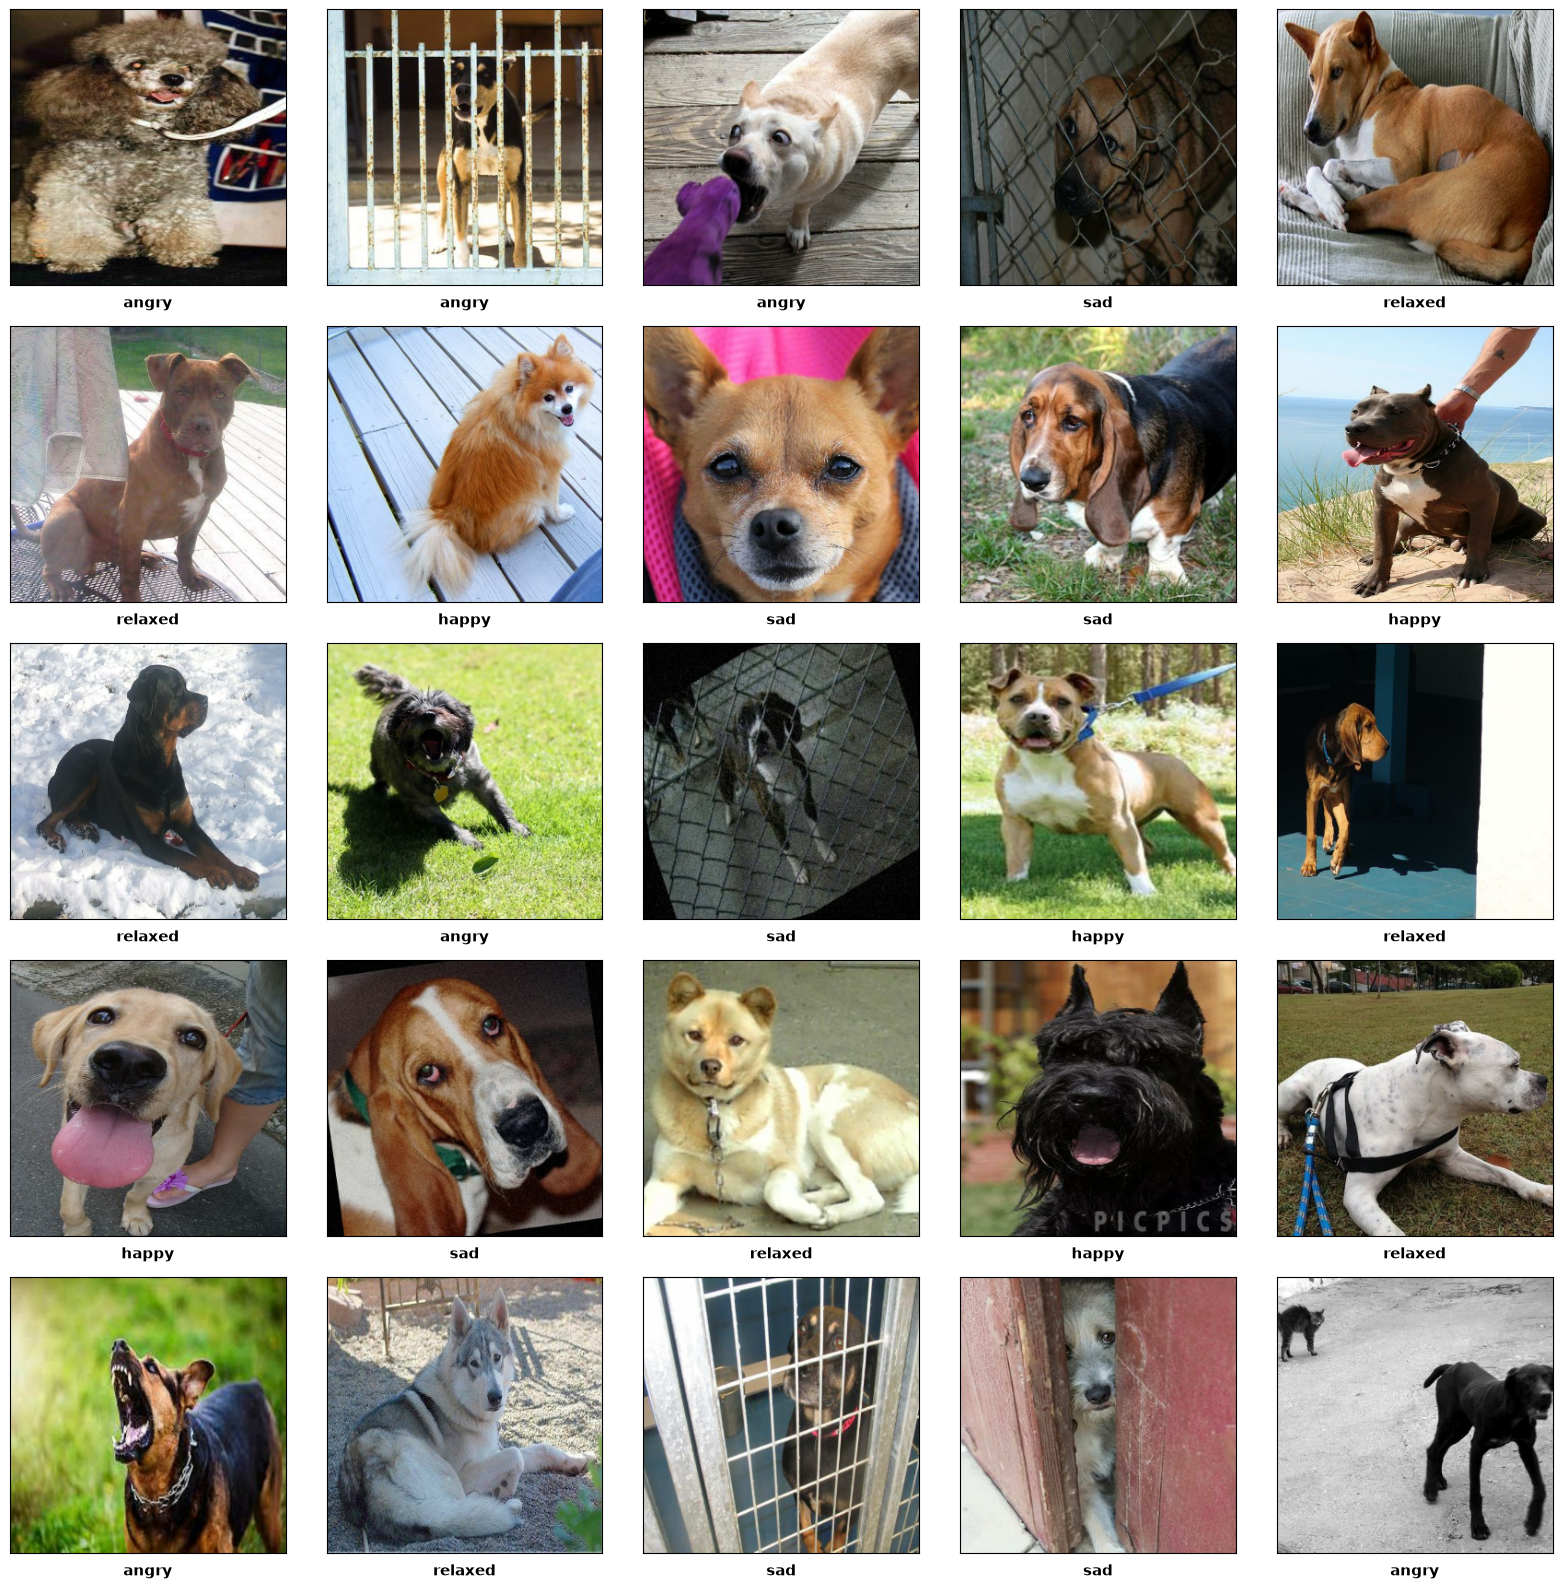

In [11]:
# Printeamos 25 imagenes de distintos baches para verificar que se ven.
images_list, labels_list = [], []

def denormalize(img):
    return (img + 1) / 2  # [-1,1] → [0,1]

for images_batch, labels_batch in train_ds.take(1):
    for img, label in zip(images_batch, labels_batch):
        images_list.append(img.numpy())
        labels_list.append(label.numpy())
        if len(images_list) == 25:
            break
    if len(images_list) == 25:
        break

# Visualizar (como arriba)
fig, axes = plt.subplots(5, 5, figsize=(16, 16))
axes = axes.flatten()

for idx in range(25):
    image = denormalize(images_list[idx])
    label_name = class_names[labels_list[idx]]

    axes[idx].imshow(image)
    axes[idx].set_xlabel(label_name, fontsize=11, fontweight='bold', labelpad=8)
    axes[idx].set_xticks([])
    axes[idx].set_yticks([])

plt.tight_layout()
plt.show()

# Data Augmentation

En esta seccion hacemos vemos el data augmentation.

Respecto al data augmentation, comento lo que entendí pq me parecio re raro:

Hay dos formas de hacer aumento de datos:
* Offline (en disco):  copias rotadas/espejadas, guardadas como archivos nuevos, y ahí sí el ds crece (pasaría de 2560 a 5120).
* Al vuelo (esta poronga? o es bueno?): las transformaciones se aplican en memoria, en el momento, sobre las mismas 2560 imágenes. No se guarda nada nuevo.

En cada época el modelo sigue viendo 2560 imágenes (80 batches de 32). Lo que cambia es que en cada pasada esas 2560 vienen con una transformación aleatoria distinta:

Época 1: ve 2560 versiones (cada foto con su flip/rotación/zoom al azar).

Época 2: ve otras 2560 versiones de las mismas fotos, pero con transformaciones diferentes.

O sea, el conteo por época no se mueve, pero a lo largo de, por ejemplo, 15 épocas, el modelo termina viendo muchas variantes de cada perro y nunca dos veces exactamente la misma imagen.

In [12]:
# esta va a ser una capa para hacer el data aug.
# El augmentation no suma imágenes al dataset

data_augmentation = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.1),
    keras.layers.RandomZoom(0.1),
])

# Crear modelo

La idea es hacer dos cosas, ANTES de inception meter el data augmentation, y luego del inception meter el nuevo clasificador.

Inception originalmente es algo como esto:

```
Imagen
   ↓
InceptionV3
   ↓
GlobalAveragePooling
   ↓
Dense(1000)
   ↓
1000 clases ImageNet
```



In [13]:
# <-- Todo esto lo podemos sacar, con lo que comentamos afuera es suficiente.

base_model = keras.applications.InceptionV3(
    include_top=False,
    weights="imagenet",
    input_shape=(299, 299, 3)
)

print("Las capas del modelo base (las muestro de la ultima a la primera):")
base_model.summary()

print("Si no le ponemos el include_top en False, aparecen la densa:")
base_model = keras.applications.InceptionV3(
    include_top=True,
    weights="imagenet",
    input_shape=(299, 299, 3)
)
base_model.summary()

base_model = keras.applications.InceptionV3(
    include_top=False,
    weights="imagenet",
    input_shape=(299, 299, 3)
)



Las capas del modelo base (las muestro de la ultima a la primera):


Model: "inception_v3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 149, 149,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 149, 149,  │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 149, 149,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 147, 147,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 147, 147,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 73, 73,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 73, 73,    │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 73, 73,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 73, 73,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 71, 71,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 71, 71,    │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 71, 71,    │          0 │ batch_normalizat

 Total params: 21,802,784 (83.17 MB)

 Trainable params: 21,768,352 (83.04 MB)

...

Model: "inception_v3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_94 (Conv2D)  │ (None, 149, 149,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 149, 149,  │         96 │ conv2d_94[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_94       │ (None, 149, 149,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_95 (Conv2D)  │ (None, 147, 147,  │      9,216 │ activation_94[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │         96 │ conv2d_95[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_95       │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_96 (Conv2D)  │ (None, 147, 147,  │     18,432 │ activation_95[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │        192 │ conv2d_96[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_96       │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 73, 73,    │          0 │ activation_96[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_97 (Conv2D)  │ (None, 73, 73,    │      5,120 │ max_pooling2d_4[… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 73, 73,    │        240 │ conv2d_97[0][0]   │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_97       │ (None, 73, 73,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_98 (Conv2D)  │ (None, 71, 71,    │    138,240 │ activation_97[0]… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 71, 71,    │        576 │ conv2d_98[0][0]   │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_98       │ (None, 71, 71,    │          0 │ batch_normalizat

 Total params: 23,851,784 (90.99 MB)

 Trainable params: 23,817,352 (90.86 MB)

 Non-trainable params: 34,432 (134.50 KB)

Por el include_top=False queda la estructura:



```
Imagen
   ↓
InceptionV3
   ↓
falta el clasificador
```



De la docu de [keras](https://keras.io/guides/transfer_learning/):

Freezing layers: understanding the trainable attribute
Layers & models have three weight attributes:

weights is the list of all weights variables of the layer.

trainable_weights is the list of those that are meant to be updated (via gradient descent) to minimize the loss during training.

non_trainable_weights is the list of those that aren't meant to be trained. Typically they are updated by the model during the forward pass.

**Si hacemos a una capa entrenable, le podemos aplicar fine tuning.**

Si le hacemos:



```python
layer.trainable = False
```

la congelamos.



In [14]:
def create_inception_model(num_classes=4, augment=True):
    '''
    Esta es una funcion que creamos para crear modelos de inceptionV3. El
    argumento num_clases sirve para definir a cuantas clases va a clasificar
    el modelo y el argumento augment define si usa data augmentation o no.
    '''

    base_model = keras.applications.InceptionV3(
        include_top=False,
        weights="imagenet",
        input_shape=(299, 299, 3),
    )
    # Congelamos el backbone: usamos las features de ImageNet tal cual,
    # solo entrenamos la cabeza nueva.
    base_model.trainable = False

    inputs = keras.Input(shape=(299, 299, 3))

    # Data augmentation como primeras capas del modelo (se desactiva sola en inference)
    # <-- Si usamos esto entonces no tenemos que usar la seccion de Data Augmentation arriba
    x = inputs
    if augment:
        x = layers.RandomFlip("horizontal")(x)
        x = layers.RandomRotation(0.1)(x)
        x = layers.RandomZoom(0.1)(x)


    # training=False fuerza que las capas de BatchNorm del backbone
    # queden en modo inferencia aunque el modelo esté entrenando la cabeza.
    x = base_model(x, training=False)

    x = layers.GlobalAveragePooling2D()(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="output")(x)

    model = keras.Model(inputs, outputs, name="inceptionV3_dog_emotion")
    return model

Veamos como funciona este preprocesado

W0000 00:00:1782510509.616217    9181 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 34330368 bytes after encountering the first element of size 34330368 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


Antes:
min = -1.0
max = 0.99556875
Después:
min = -1.0078431
max = -0.9921916


W0000 00:00:1782510510.106708    9181 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 34330368 bytes after encountering the first element of size 34330368 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


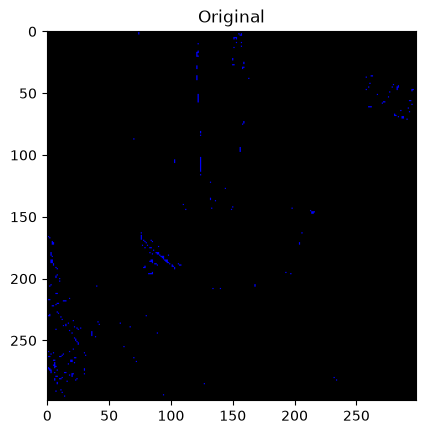

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0078431..-0.99218047].


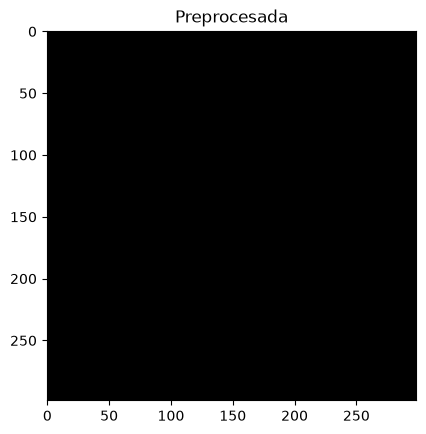

In [15]:
# <-- Esta parte media inecesaria...

for images, labels in train_ds.take(1):

    img = images[0]

    print("Antes:")
    print("min =", np.min(img))
    print("max =", np.max(img))

    img_pre = keras.applications.inception_v3.preprocess_input(img)

    print("Después:")
    print("min =", np.min(img_pre))
    print("max =", np.max(img_pre))

for images, labels in train_ds.take(1):

    img = images[0].numpy()

    plt.imshow(img.astype("uint8"))
    plt.title("Original")
    plt.show()

    img_pre = keras.applications.inception_v3.preprocess_input(img)

    plt.imshow(img_pre)
    plt.title("Preprocesada")
    plt.show()

# Primer entrenamiento - Una sola capa

Ahora que ya tenemos una funcion para crear modelos podemos crearlo y entrenarlo congelando todas las capas menos la ultima capa densa.

In [16]:
# Ahora que tenemos la funcion creamos el modelo y lo entrenamos
# en el primer caso le congelamos todas las capas menos la ultima.
model = create_inception_model(num_classes=4)

# Congelar todas las capas de menos las ultimas
for layer in model.layers:
  if layer.name != 'output':
    print(f'Congelando {layer.name}')
    layer.trainable = False

model.summary()

Congelando input_layer_4
Congelando random_flip_1
Congelando random_rotation_1
Congelando random_zoom_1
Congelando inception_v3
Congelando global_average_pooling2d


Model: "inceptionV3_dog_emotion"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_1 (RandomFlip)      │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 299, 299, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_v3 (Functional)       │ (None, 8, 8, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │         8,196 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,810,980 (83.20 MB)

 Trainable params: 8,196 (32.02 KB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [28]:
# Entrenemos entonces
def train_model(x_train, y_train, x_val, y_val, cnn_model,
                optimizer, loss, metrics, batch_size, epochs, history_path):
    print("\nStarting CNN training...")

    cnn_model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

    logger = keras.callbacks.CSVLogger(history_path, append=False)

    history = cnn_model.fit(
        x_train, y_train,
        batch_size=batch_size,
        epochs=epochs,
        validation_data=(x_val, y_val),
        callbacks=[logger],
        verbose=1,
    )
    print("\nCNN training completed!")

    return history, cnn_model

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"])

modelHistory = model.fit(train_ds, validation_data=val_ds,
                     epochs=50)

Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 29s 125ms/step - accuracy: 0.7137 - loss: 0.7344 - val_accuracy: 0.6891 - val_loss: 0.7504
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - accuracy: 0.7242 - loss: 0.7177 - val_accuracy: 0.7219 - val_loss: 0.7304
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 7s 87ms/step - accuracy: 0.7367 - loss: 0.6929 - val_accuracy: 0.7219 - val_loss: 0.7413
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - accuracy: 0.7324 - loss: 0.6945 - val_accuracy: 0.7375 - val_loss: 0.7079
Epoch 5/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 7s 89ms/step - accuracy: 0.7406 - loss: 0.6704 - val_accuracy: 0.7125 - val_loss: 0.7433
Epoch 6/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 7s 89ms/step - accuracy: 0.7355 - loss: 0.6742 - val_accuracy: 0.7406 - val_loss: 0.6903
Epoch 7/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - accuracy: 0.7652 - loss: 0.6497 - val_accuracy: 0.7219 - val_loss: 0.7057
Epoch 8/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 7s 90ms/step - accuracy: 0.7504 - loss: 0.6591 - val_accuracy: 0.7437 -

In [ ]:
callbacks = [
    keras.callbacks.EarlyStopping(patience=4, restore_best_weights=True,
                                  monitor="val_accuracy"),
]

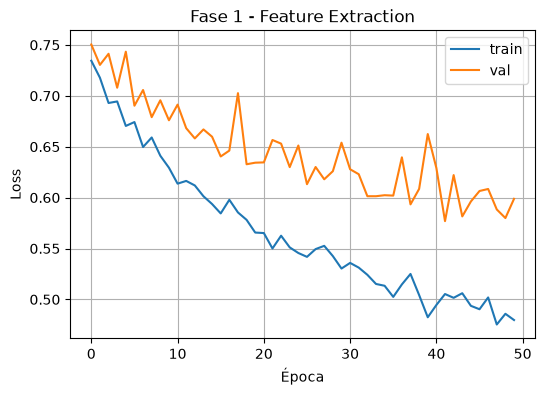

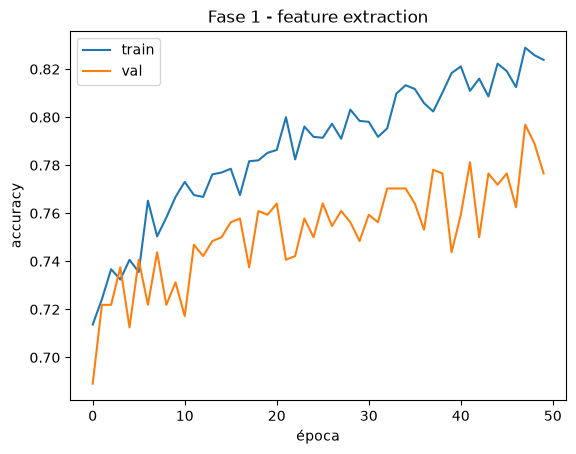

25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step

Resultados:
Correctas: 627/800
Accuracy: 0.7837 (78.38%)
Error: 0.2163 (21.63%)


In [29]:
def plot_history(h, titulo):
    plt.plot(h.history["accuracy"], label="train")
    plt.plot(h.history["val_accuracy"], label="val")
    plt.title(titulo); plt.xlabel("época"); plt.ylabel("accuracy")
    plt.legend(); plt.show()

def plot_loss(h, titulo):
    plt.figure(figsize=(6,4))
    plt.plot(h.history["loss"], label="train")
    plt.plot(h.history["val_loss"], label="val")
    plt.title(titulo)
    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_loss(modelHistory, "Fase 1 - Feature Extraction")

plot_history(modelHistory, "Fase 1 - feature extraction")


def show_evaluation_results(model, test_ds):
    predictions = model.predict(test_ds, verbose=1)

    y_pred = np.argmax(predictions, axis=1)

    y_true = np.concatenate([y.numpy() for _, y in test_ds])

    correct = np.sum(y_pred == y_true)
    accuracy = correct / len(y_true)
    error_rate = 1 - accuracy

    print("\nResultados:")
    print(f"Correctas: {correct}/{len(y_true)}")
    print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"Error: {error_rate:.4f} ({error_rate*100:.2f}%)")

show_evaluation_results(model, test_ds)

In [25]:
print(len(modelHistory.history['loss']))

10


# **Guardar y Cargar Modelos e Historias de Entrenamiento**

A continuación definimos funciones útiles para guardar el modelo y su historial de entrenamiento en disco (con soporte para descargarlo/cargarlo automáticamente si estás usando Google Colab).

In [30]:
import pickle
import os

def guardar_modelo_y_historial(model, history, base_name='modelo_inception_dogs'):
    """
    Guarda el modelo de Keras y su historial de entrenamiento en archivos.
    Soporta descarga automática si se ejecuta en Google Colab.
    """
    # Guardar el modelo. Usamos el nombre base tal como se solicita.
    model_path = f"{base_name}.keras"
    model.save(model_path)
    print(f"Modelo guardado exitosamente en: {model_path}")
    
    # Obtener el diccionario del historial y guardarlo con pickle
    history_dict = history.history if hasattr(history, 'history') else history
    history_path = f"{base_name}_history.pkl"
    with open(history_path, 'wb') as f:
        pickle.dump(history_dict, f)
    print(f"Historial guardado exitosamente en: {history_path}")
    
    # Si estamos en Google Colab, descargamos los archivos automáticamente
    try:
        from google.colab import files
        # Si el modelo se guardó como carpeta (SavedModel sin extensión), se comprime para facilitar la descarga
        if os.path.isdir(model_path):
            import zipfile
            zip_path = f"{model_path}.zip"
            with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
                for root, dirs, files_in_dir in os.walk(model_path):
                    for file in files_in_dir:
                        zipf.write(os.path.join(root, file), 
                                   os.path.relpath(os.path.join(root, file), os.path.join(model_path, '..')))
            print(f"Modelo comprimido en {zip_path} para su descarga.")
            files.download(zip_path)
        else:
            files.download(model_path)
        files.download(history_path)
        print("Descargas iniciadas en Google Colab.")
    except ImportError:
        print("Entorno local detectado. Los archivos permanecen guardados en el disco local.")

# Guardar el modelo e historial entrenado (Fase 1)
guardar_modelo_y_historial(model, modelHistory, 'modelo_inception_dogs')

Modelo guardado exitosamente en: modelo_inception_dogs.keras
Historial guardado exitosamente en: modelo_inception_dogs_history.pkl
Entorno local detectado. Los archivos permanecen guardados en el disco local.


In [31]:
from tensorflow.keras.models import load_model
import pickle
import os

def cargar_modelo_y_historial(base_name='modelo_inception_dogs'):
    """
    Permite subir archivos si se ejecuta en Google Colab y carga el modelo junto con su historial.
    """
    model_path = f"{base_name}.keras"
    history_path = f"{base_name}_history.pkl"
    
    # Si estamos en Google Colab, solicita subir los archivos
    try:
        from google.colab import files
        print(f"Por favor, subí el modelo ({model_path}) y el historial ({history_path}):")
        uploaded = files.upload()
        # Si se subió un archivo zip (por haber guardado el modelo como carpeta)
        zip_path = f"{model_path}.zip"
        if zip_path in uploaded and not os.path.exists(model_path):
            import zipfile
            with zipfile.ZipFile(zip_path, 'r') as zip_ref:
                zip_ref.extractall(".")
            print(f"Modelo descomprimido desde {zip_path}")
    except ImportError:
        print("Entorno local detectado. Cargando archivos directamente desde el directorio de trabajo.")
        
    # Cargar el modelo
    modelo_cargado = load_model(model_path)
    print(f"Modelo cargado exitosamente desde: {model_path}")
    
    # Cargar el historial
    with open(history_path, 'rb') as f:
        history_cargado = pickle.load(f)
    print(f"Historial cargado exitosamente desde: {history_path}")
    
    return modelo_cargado, history_cargado

# Ejemplo de uso (para cargar y hacer predicciones):
# modelo_recuperado, historial_recuperado = cargar_modelo_y_historial('modelo_inception_dogs')
# predicciones = modelo_recuperado.predict(test_ds)
# print("Predicciones realizadas de forma exitosa sobre test_ds.")

# Fine tuning
Ahora descongelamos las últimas capas convolucionales para que se ajusten a perros

* Descongelar solo las últimas N capas

* Usar un learning rate muy bajo (1-5). Si usamos uno alto, matamos el conocimiento preentrenado

# Exploraciones

hay que definirlas, algunas que me recomendo CLAUDE ^.^:

| Exploración                         | Cómo hacerla                                                                                                                                                                          |
| ----------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Profundidad de descongelamiento** | Repetí la Fase 2 con `FINE_TUNE_AT =` últimas 0, 30, 50 y 100 capas. Anotá el `val_accuracy` de cada una en una tabla.                                                                |
| **Cantidad de épocas**              | Mirá las curvas de `history1` y `history2`. ¿En qué época deja de mejorar `val_accuracy`?                                                                                             |
| **Overfitting**                     | Graficá `train_accuracy` vs `val_accuracy`. Si `train_accuracy` sigue subiendo mientras `val_accuracy` se estanca o baja, hay overfitting. El gap entre ambas curvas permite medirlo. |
| **Métricas**                        | Compará **Accuracy**, **Precision**, **Recall** y **F1-Score** entre la **Fase 1** (solo cabezal) y la **Fase 2** (fine-tuning).                                                      |


# Evaluación con las 4 métricas

Accuracy, Precision, Recall y F1

# App de cámara (a definir si lo metemos aca o aparte)

de esto a tener en cuenta:

OpenCV abre la imagen en BGR y la red espera RGB. Por eso el cvtColor.

El preprocesado de la cámara tiene que ser idéntico al del entrenamiento (resize a 299x299 y preprocess_input).